# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np
import pandas as pd

In [2]:
arr1=np.random.normal(0,3,1000).round(3)
arr1

array([ 7.660e-01,  5.930e-01,  3.760e+00,  6.960e-01, -2.235e+00,
        1.872e+00,  4.600e-02, -7.110e-01,  1.732e+00, -2.217e+00,
        2.992e+00,  7.098e+00, -5.347e+00, -4.676e+00, -4.742e+00,
        3.617e+00,  2.759e+00,  5.274e+00,  1.380e-01, -1.113e+00,
        4.722e+00,  7.300e-02, -2.990e+00,  2.011e+00, -7.740e-01,
       -2.286e+00,  1.070e+00,  5.377e+00, -3.000e-01,  6.909e+00,
       -1.386e+00, -4.573e+00, -6.799e+00,  4.527e+00,  9.050e-01,
        6.407e+00,  3.555e+00, -4.051e+00, -1.140e-01,  2.487e+00,
       -1.369e+00,  2.784e+00,  2.327e+00, -3.230e-01, -1.878e+00,
        5.272e+00,  5.540e+00,  2.801e+00, -1.358e+00, -2.982e+00,
       -1.820e+00, -5.444e+00, -8.790e-01, -4.810e-01, -1.653e+00,
       -1.164e+00,  3.918e+00, -1.119e+00,  3.883e+00,  1.080e+00,
        3.911e+00, -2.778e+00,  4.160e-01, -3.289e+00, -1.096e+00,
       -6.826e+00,  4.458e+00,  1.150e+00,  8.330e-01,  5.124e+00,
        2.394e+00, -6.548e+00, -1.040e+00, -5.124e+00,  2.321e

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [3]:
cont, disc = "expressao_gen", "num_genes"

df2 = pd.DataFrame({
        cont: arr1,
        disc: np.random.randint(0,1001,1000)
    },
).round(3)

'''outra possibilidade seria:
df2 = pd.DataFrame({
        "expressao_gen": arr1,
        "num_genes": np.random.randint(0,1001,1000)
    },
).round(3)'''

df2.head()

,expressao_gen,num_genes
0,0.766,557
1,0.593,529
2,3.760,14
3,0.696,404
4,-2.235,527


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: 

In [4]:
print(df2.iloc[:,0].min())
print(df2.iloc[:,0].max())
df2.iloc[:,0].max()-df2.iloc[:,0].min()

-7.785
10.82


np.float64(18.605)

In [5]:
'''categorizei em 6 níveis de expressão, incluindo uma faixa de expressão nula na faixa de -2 a 2. 
Para determinar os valores de cut considerei os valores maximos e minimos de expressão encontrados no dataset, definindo os intervalos:
-10 a -5, -5 a -2, -2 a 2, 2 a 5, 5 a 7.5 e 7.5 a 10'''

labels = ['Exp dim', 'Exp down', 'Exp null', 'Exp up', 'Exp high', 'Exp bright']
df2[cont+" cat"] = pd.cut(df2[cont], bins=[-10.0, -5.0, -2.0, 2.0, 5.0, 7.5, 10.0], labels=labels)
df2.iloc[0:10,:]

,expressao_gen,num_genes,expressao_gen cat
0,0.766,557,Exp null
1,0.593,529,Exp null
2,3.760,14,Exp up
3,0.696,404,Exp null
4,-2.235,527,Exp down
5,1.872,769,Exp null
6,0.046,657,Exp null
7,-0.711,506,Exp null
8,1.732,918,Exp null
9,-2.217,179,Exp down


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [6]:
def tabela_frequencia(dados) -> pd.DataFrame:
    
    serie = pd.Series(dados)
    
    freq_abs = serie.value_counts().sort_index()
    
    df = freq_abs.to_frame(name='Freq Abs Simp')
    
    total = df['Freq Abs Simp'].sum()
    
    df['Freq Rel Simp'] = df['Freq Abs Simp'] / total
    df['Freq Abs Acum'] = df['Freq Abs Simp'].cumsum()
    df['Freq Rel Acum'] = df['Freq Rel Simp'].cumsum()
    
    linha_total = pd.DataFrame({
        'Freq Abs Simp': [total],
        'Freq Rel Simp': [1.0],
        'Freq Abs Acum': [np.nan],
        'Freq Rel Acum': [np.nan]
    }, index=['Total'])
    
    df_final = pd.concat([df, linha_total])
    
    return df_final

In [7]:
tab_exp=tabela_frequencia(df2['expressao_gen'])
display(tab_exp)

,Freq Abs Simp,Freq Rel Simp,Freq Abs Acum,Freq Rel Acum
-7.785,1,0.001,1.0,0.001
-7.727,1,0.001,2.0,0.002
-7.696,1,0.001,3.0,0.003
-7.558,1,0.001,4.0,0.004
-7.422,1,0.001,5.0,0.005
...,...,...,...,...
8.291,1,0.001,997.0,0.997
9.169,1,0.001,998.0,0.998
9.767,1,0.001,999.0,0.999
10.82,1,0.001,1000.0,1.000


In [8]:
tab_num=tabela_frequencia(df2['num_genes'])
tab_num

,Freq Abs Simp,Freq Rel Simp,Freq Abs Acum,Freq Rel Acum
0,3,0.003,3.0,0.003
1,1,0.001,4.0,0.004
2,1,0.001,5.0,0.005
5,1,0.001,6.0,0.006
6,1,0.001,7.0,0.007
...,...,...,...,...
996,2,0.002,995.0,0.995
997,1,0.001,996.0,0.996
998,1,0.001,997.0,0.997
1000,3,0.003,1000.0,1.000


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

In [43]:
import matplotlib.pyplot as plt
def plot_frequencias(tabela, titulo_base):
    
    tabela_plot = tabela.loc[tabela.index != 'Total']
    
    plt.figure()
    plt.bar(tabela_plot.index, tabela_plot['Freq Abs Simp'])
    plt.title(f'{titulo_base} - Frequência Absoluta Simples')
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()
    
    plt.figure()
    plt.plot(tabela_plot.index, tabela_plot['Freq Rel Acum'], marker='o')
    plt.title(f'{titulo_base} - Frequência Absoluta Acumulada')
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

### Expressão

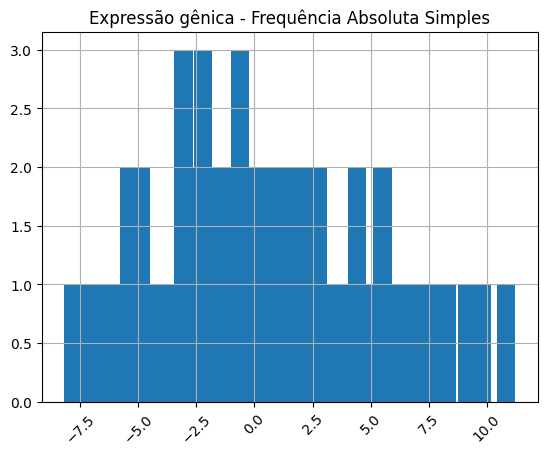

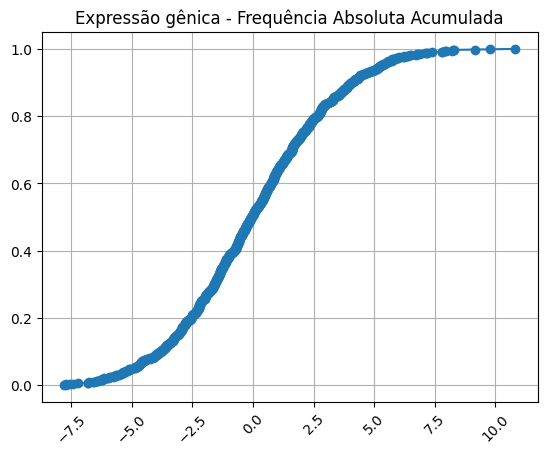

In [10]:
plot_frequencias(tab_exp,'Expressão gênica')

### Número

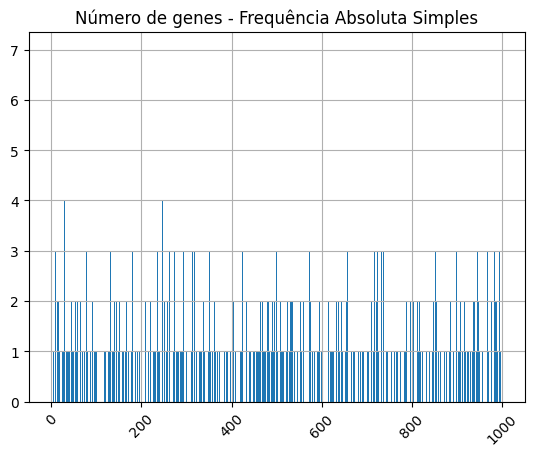

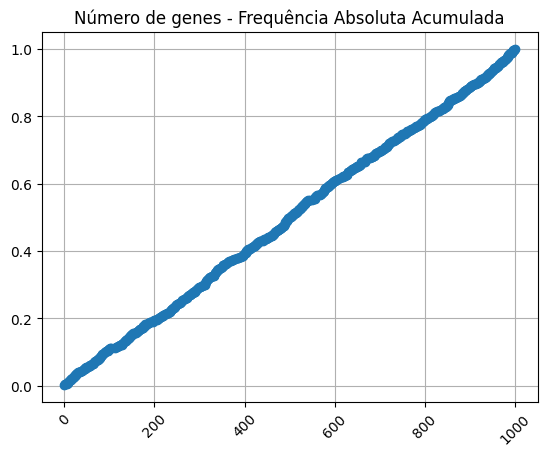

In [11]:
plot_frequencias(tab_num,'Número de genes')

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

In [16]:
import seaborn as sns

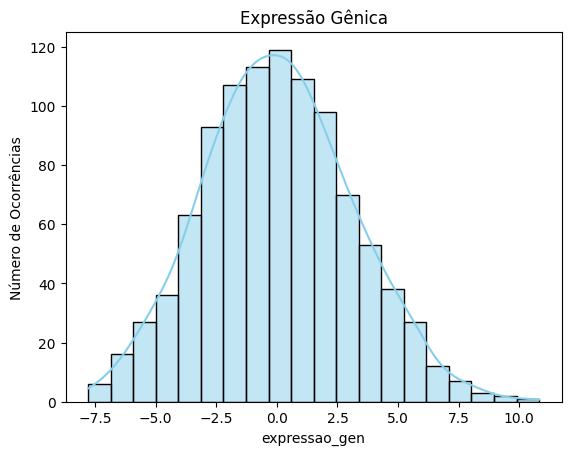

In [13]:
#EXPRESSAO GENICA
sns.histplot(
    x=cont,
    kde=True,
    bins=20,
    color='skyblue',
    data=df2,
)
plt.title("Expressão Gênica")
plt.xlabel(cont)
plt.ylabel("Número de Ocorrências")
plt.show()

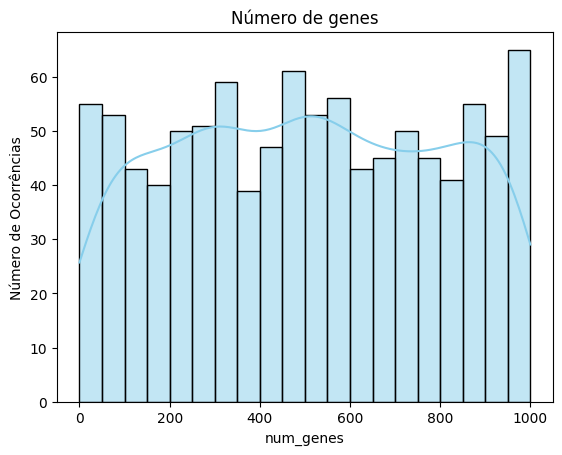

In [18]:
#NUMERO DE GENES
sns.histplot(
    x=disc,
    kde=True,
    bins=20,
    color='skyblue',
    data=df2,
)
plt.title("Número de genes")
plt.xlabel(disc)
plt.ylabel("Número de Ocorrências")
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

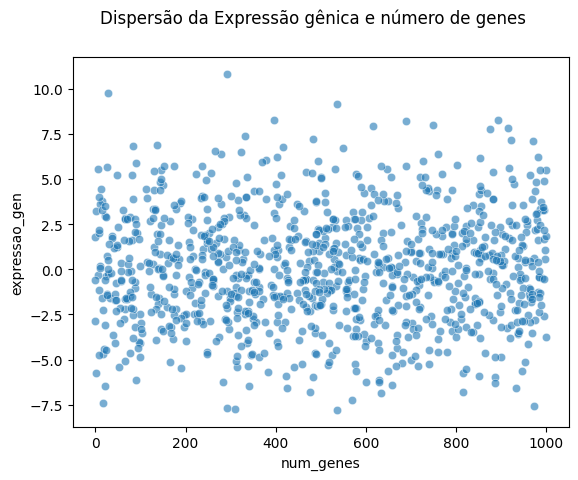

In [45]:
sns.scatterplot(
    x=disc,
    y=cont,
    data=df2,
    alpha=0.6
)
plt.suptitle("Dispersão da Expressão gênica e número de genes")
plt.show()

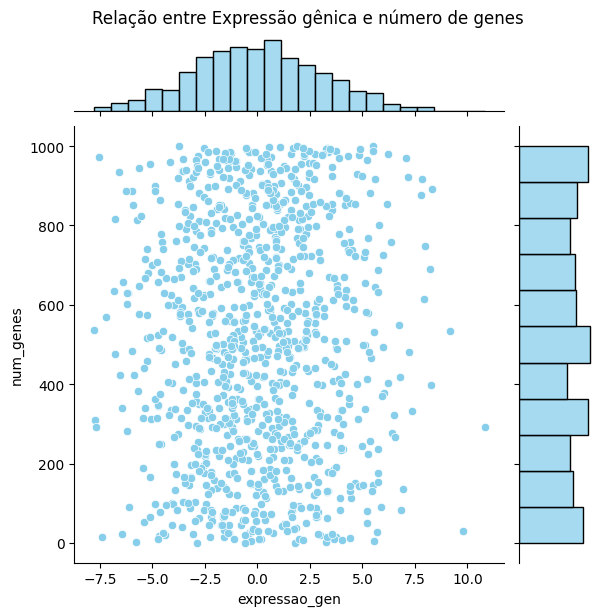

In [35]:
sns.jointplot(
    x=cont,
    y=disc,
    data=df2,
    kind='scatter',
    color='skyblue',
)
plt.suptitle("Relação entre Expressão gênica e número de genes", y=1.02)
plt.xlabel(cont)
plt.ylabel(disc)
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

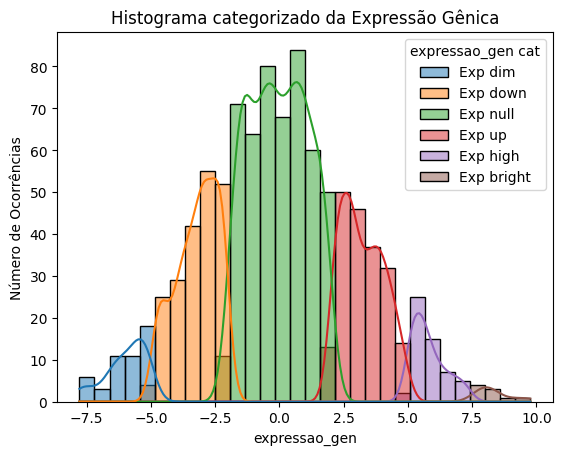

In [32]:
sns.histplot(
    x=cont,
    kde=True,
    bins=30,
    color='skyblue',
    hue=cont+" cat",
    data=df2,
)
plt.title("Histograma categorizado da Expressão Gênica")
plt.xlabel(cont)
plt.ylabel("Número de Ocorrências")
plt.show()

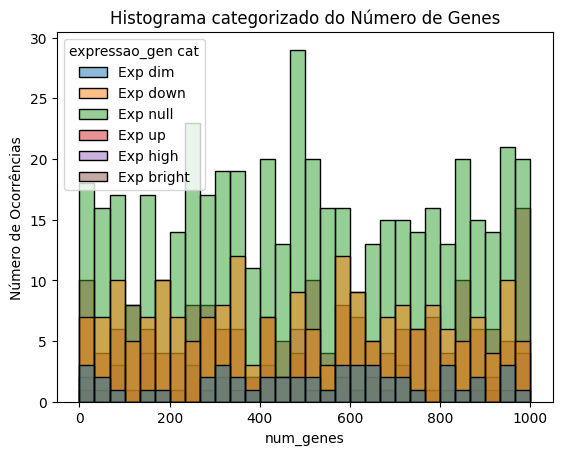

In [31]:
sns.histplot(
    x=disc,
    kde=False,
    bins=30,
    hue=cont+" cat",
    data=df2,
)
plt.title("Histograma categorizado do Número de Genes")
plt.xlabel(disc)
plt.ylabel("Número de Ocorrências")
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

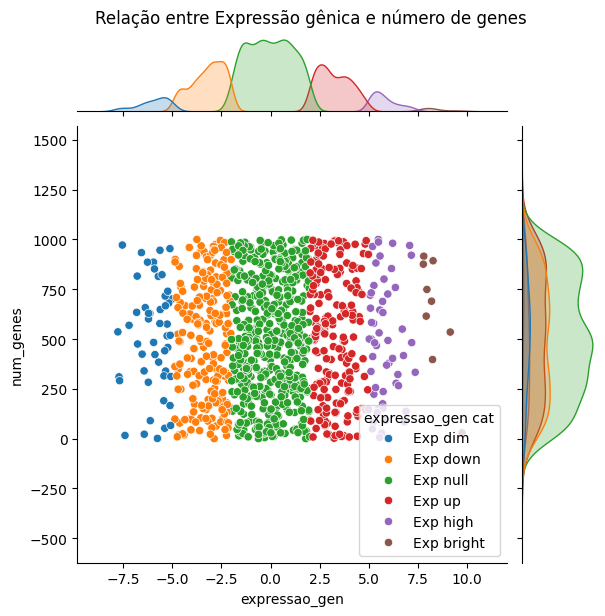

In [41]:
sns.jointplot(
    x=cont,
    y=disc,
    data=df2,
    hue=cont+" cat",
    kind='scatter',
    color='skyblue',
)
plt.suptitle("Relação entre Expressão gênica e número de genes", y=1.02)
plt.xlabel(cont)
plt.ylabel(disc)
plt.show()

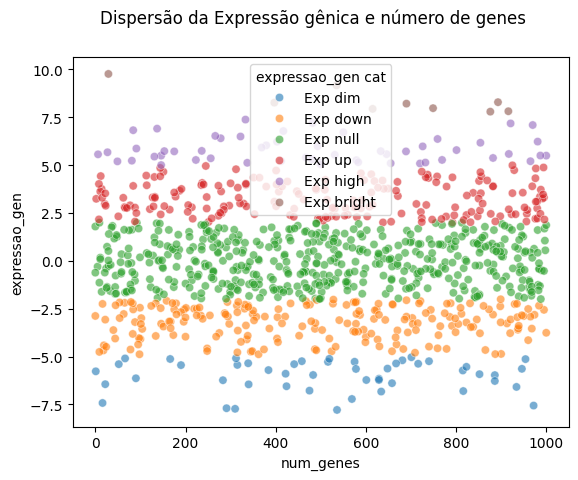

In [44]:
sns.scatterplot(
    x=disc,
    y=cont,
    data=df2,
    hue=cont+" cat",
    alpha=0.6
)
plt.suptitle("Dispersão da Expressão gênica e número de genes")
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|discreta|
| % de células positivas|contínua|
| Faixa de pH|ordinal|
| Valor de pH|contínua|
| mol/L|contínua|
| UFC|discreta|
| D.O.|contínua|
| Grupo Sanguíneo|nominal|
| Sorologia|ordinal ou nominal|